# Coding Exercises (Part 1)

Now, you will have the opportunity to practice what you have learned. <br>
__Follow the instructions__ and insert your code! 

The correct answer is provided below your coding cell. There you can check whether your code is correct.

If you need some help or if you want to check your code, you can also have a look at the __solutions__.

### Have Fun!

--------------------------------------------------------------------------------------------------------------

## Exercise 8:  Complex TVM and Capital Budgeting problems with Python and Numpy

In [3]:
# run the cell
import numpy as np
import pandas as pd
import numpy_financial as npf # NEW!!!

import matplotlib.pyplot as plt
%config InlineBackened.figure_format = "svg"
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

The ABC Company evaluates to buy an additional machine that will increase future profits/cashflows by
- 50 USD in t1, 
- 80 USD in t2,
- 120 USD in t3, 
- 150 USD in t4,
- 200 USD in t5. (each cf at period´s end)<br>

The machine costs 500 USD (Investment in to). ABC´s required rate of return (Cost of Capital) is 7.5% p.a. 

In [4]:
cf = np.array([-500 , 50 , 80 , 120 , 150 , 200])
cf

array([-500,   50,   80,  120,  150,  200])

In [5]:
r = 7.5/100 # the required rate of return (cost of capital)
r

0.075

1. Calculate the Net __Present Value (NPV)__ of the Project with __numpy financial functions__.

In [6]:
npf.npv(rate = r , values = cf)

np.float64(-36.03468883756554)

2. Calculate the __IRR__ of the Project with __numpy financial functions__.

In [7]:
irr = npf.irr(cf)
irr

0.05234347404159134

3. Should ABC __accept or reject__ the project?

Answer: We decline the project because the irr is less than the required rate of return

4. Assume a 20-year-old investor wants to retire in 45 years at the age of 65. He expects to earn 4.5% p.a. on his Investment during the Funding Phase and during the Payout Phase. He plans to start depositing 500 USD at the end of each month for n years in order to be able to withdraw 3,000 USD per month (at the beginning of each month) for 30 years during retirement. The Annuity Contract´s final Value shall be 50,000 USD when he is 95 years old (to cover some more years). __In how many months will the investor´s funding phase start__?

__Payout Phase__

In [8]:
cf_outflow = 3000 # outflow from the account during the retirement period
r = 4.5/100 # interest rate during the funding period & payout period
n2 = 30 # years of payout period
m = 12 
FV2 = 50000 # final value of the account

In [9]:
PV2 = npf.pv(rate = r/m , nper = n2*m , pmt = cf_outflow , fv = FV2 , when = "begin")
PV2

np.float64(-607298.5727512676)

In [10]:
PV2_array = npf.pv(rate = r/m , nper = np.arange(0 , n2*m + 1) , pmt = cf_outflow , fv = FV2 , when = "begin")
PV2_array

array([ -50000.        ,  -52813.20049813,  -55615.89090723,
        -58408.11049288,  -61189.89837398,  -63961.29352327,
        -66722.33476789,  -69473.06078992,  -72213.51012695,
        -74943.72117255,  -77663.73217689,  -80373.58124721,
        -83073.3063484 ,  -85762.94530352,  -88442.53579429,
        -91112.11536168,  -93771.72140641,  -96421.39118945,
        -99061.16183257, -101691.07031888, -104311.15349328,
       -106921.44806304, -109521.9905983 , -112112.81753255,
       -114693.96516319, -117265.46965199, -119827.36702565,
       -122379.69317624, -124922.48386176, -127455.77470661,
       -129979.6012021 , -132493.99870695, -134999.00244777,
       -137494.64751957, -139980.96888625, -142458.00138107,
       -144925.77970716, -147384.33843802, -149833.71201795,
       -152273.93476259, -154705.04085937, -157127.06436799,
       -159540.03922091, -161943.99922382, -164338.97805611,
       -166725.00927135, -169102.12629773, -171470.36243858,
       -173829.75087281,

In [11]:
-PV2_array[::-1][-1]

np.float64(50000.0)

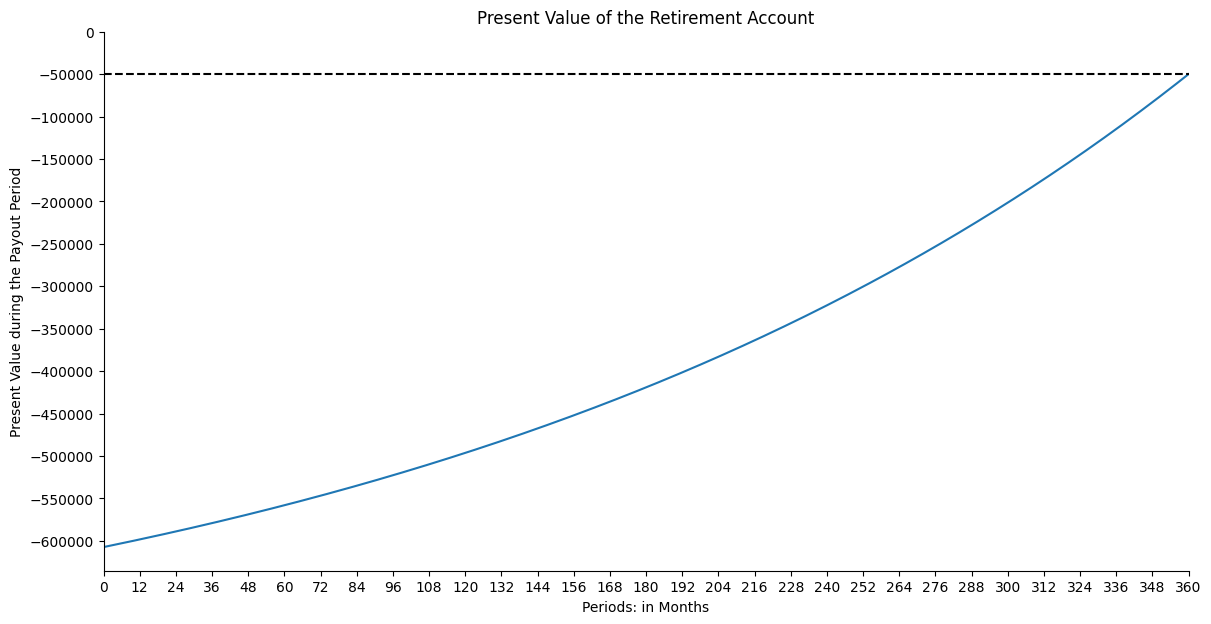

In [12]:
plt.figure(figsize = (14,7))
plt.plot(np.arange(n2*m+1) , PV2_array[::-1])

plt.title("Present Value of the Retirement Account")
plt.xlabel("Periods: in Months")
plt.ylabel("Present Value during the Payout Period")

plt.xticks(np.arange(0, n2*m +12, 12))
plt.xlim ((0, n2*m))


plt.axhline(y = PV2_array[::-1][-1], color = "black", linestyle = "dashed")
plt.yticks(np.arange(0 , PV2_array[-1] , -50000))

ax = plt.gca()
ax.spines[["right", "top"]].set_visible(False)
plt.show()

So we could find the FV of the Funding phase period whuich is the PV of the payout phase period.

__Funding Phase__

In [13]:
#n1 = ?
m = 12 # compounding frequency
cf_inflow = 500
r = 4.5/100 # interest rate during the funding period
FV1 = -PV2
PV1 = 0


In [14]:
n = npf.nper(rate = r/m , pmt = -cf_inflow , pv = PV1 , fv = FV1)
n

array(458.09718839)

In [15]:
12 * 45 - np.ceil(n)

np.float64(81.0)

In [16]:
n_s = npf.nper(rate = r/m , pmt = -cf_inflow , pv = PV2_array , fv = FV1)
12 * 45 - np.ceil(n_s)

array([166., 171., 175., 178., 182., 186., 190., 193., 197., 201., 204.,
       207., 211., 214., 217., 221., 224., 227., 230., 233., 236., 239.,
       242., 244., 247., 250., 253., 255., 258., 261., 263., 266., 268.,
       271., 273., 276., 278., 280., 283., 285., 287., 289., 292., 294.,
       296., 298., 300., 302., 304., 306., 308., 310., 312., 314., 316.,
       318., 320., 322., 324., 326., 327., 329., 331., 333., 334., 336.,
       338., 340., 341., 343., 344., 346., 348., 349., 351., 352., 354.,
       355., 357., 358., 360., 361., 363., 364., 366., 367., 369., 370.,
       371., 373., 374., 375., 377., 378., 379., 381., 382., 383., 384.,
       386., 387., 388., 389., 391., 392., 393., 394., 395., 397., 398.,
       399., 400., 401., 402., 403., 404., 406., 407., 408., 409., 410.,
       411., 412., 413., 414., 415., 416., 417., 418., 419., 420., 421.,
       422., 423., 424., 425., 426., 427., 428., 428., 429., 430., 431.,
       432., 433., 434., 435., 436., 436., 437., 43

You consider to buy a new home for a Purchase Price of 700,000 USD. You decide to pay 300,000 USD cash. Therefore, you require another 400,000 USD from a Bank (Amortizing Mortgage) to realize the Deal. You agree with your local Bank on the following Mortgage terms:
- Fixed interest rate: 4.2% p.a. (compounded monthly)
- Loan Term with fixed interest rate is 35 years
- Outstanding Loan Amount after 35 Years shall be 0 USD
- Loan payments (interest & amortization) shall be made monthly in arrears 

5. Calculate the required __constant monthly payments__.

In [17]:
house_price = 700000 #USD
down_payment = 300000 #USD
loan_amount = house_price - down_payment # 400000 #USD
interest_rate = 4.2/100
n_years = 35
m = 12

In [18]:
monthly_payment = npf.pmt(rate = interest_rate/m , nper = n_years*m , pv = loan_amount)
monthly_payment

np.float64(-1819.401880466396)

6. Calculate the __Repayment / Amortization Schedule__ on a monthly basis for the next 35 years. What is the amortization amount in the __very last period/month__?

In [19]:
amortization_last_month = npf.ppmt(rate = interest_rate/m , per = n_years*m , nper = n_years*m , pv = loan_amount)
amortization_last_month

np.float64(-1813.0561838230158)

In [20]:
amortizations = npf.ppmt(rate = interest_rate/m , per = np.arange(1, n_years*m+1) , nper = n_years*m , pv = loan_amount)
amortizations

array([ -419.40188047,  -420.86978705,  -422.3428313 ,  -423.82103121,
        -425.30440482,  -426.79297024,  -428.28674563,  -429.78574924,
        -431.28999937,  -432.79951436,  -434.31431266,  -435.83441276,
        -437.3598332 ,  -438.89059262,  -440.42670969,  -441.96820318,
        -443.51509189,  -445.06739471,  -446.62513059,  -448.18831855,
        -449.75697766,  -451.33112709,  -452.91078603,  -454.49597378,
        -456.08670969,  -457.68301317,  -459.28490372,  -460.89240088,
        -462.50552429,  -464.12429362,  -465.74872865,  -467.3788492 ,
        -469.01467517,  -470.65622653,  -472.30352333,  -473.95658566,
        -475.61543371,  -477.28008773,  -478.95056803,  -480.62689502,
        -482.30908915,  -483.99717097,  -485.69116106,  -487.39108013,
        -489.09694891,  -490.80878823,  -492.52661899,  -494.25046216,
        -495.98033877,  -497.71626996,  -499.4582769 ,  -501.20638087,
        -502.96060321,  -504.72096532,  -506.4874887 ,  -508.26019491,
      

In [21]:
interests = npf.ipmt(rate = interest_rate/m , per = np.arange(1, n_years*m+1) , nper = n_years*m , pv = loan_amount)
interests

array([-1400.        , -1398.53209342, -1397.05904916, -1395.58084925,
       -1394.09747564, -1392.60891023, -1391.11513483, -1389.61613122,
       -1388.1118811 , -1386.6023661 , -1385.0875678 , -1383.56746771,
       -1382.04204726, -1380.51128785, -1378.97517077, -1377.43367729,
       -1375.88678858, -1374.33448576, -1372.77674987, -1371.21356192,
       -1369.6449028 , -1368.07075338, -1366.49109444, -1364.90590668,
       -1363.31517078, -1361.71886729, -1360.11697675, -1358.50947958,
       -1356.89635618, -1355.27758685, -1353.65315182, -1352.02303127,
       -1350.3872053 , -1348.74565393, -1347.09835714, -1345.44529481,
       -1343.78644676, -1342.12179274, -1340.45131243, -1338.77498544,
       -1337.09279131, -1335.4047095 , -1333.7107194 , -1332.01080034,
       -1330.30493156, -1328.59309224, -1326.87526148, -1325.15141831,
       -1323.42154169, -1321.68561051, -1319.94360356, -1318.19549959,
       -1316.44127726, -1314.68091515, -1312.91439177, -1311.14168556,
      

In [22]:
interests + amortizations

array([-1819.40188047, -1819.40188047, -1819.40188047, -1819.40188047,
       -1819.40188047, -1819.40188047, -1819.40188047, -1819.40188047,
       -1819.40188047, -1819.40188047, -1819.40188047, -1819.40188047,
       -1819.40188047, -1819.40188047, -1819.40188047, -1819.40188047,
       -1819.40188047, -1819.40188047, -1819.40188047, -1819.40188047,
       -1819.40188047, -1819.40188047, -1819.40188047, -1819.40188047,
       -1819.40188047, -1819.40188047, -1819.40188047, -1819.40188047,
       -1819.40188047, -1819.40188047, -1819.40188047, -1819.40188047,
       -1819.40188047, -1819.40188047, -1819.40188047, -1819.40188047,
       -1819.40188047, -1819.40188047, -1819.40188047, -1819.40188047,
       -1819.40188047, -1819.40188047, -1819.40188047, -1819.40188047,
       -1819.40188047, -1819.40188047, -1819.40188047, -1819.40188047,
       -1819.40188047, -1819.40188047, -1819.40188047, -1819.40188047,
       -1819.40188047, -1819.40188047, -1819.40188047, -1819.40188047,
      

In [ ]:
remaining_balance = npf.fv(rate = interest_rate/m , nper = np.arange(1,n_years*m+1) , pmt = monthly_payment , pv = loan_amount)
remaining_balance 

array([-399580.59811953, -399159.72833249, -398737.38550118,
       -398313.56446997, -397888.26006515, -397461.46709491,
       -397033.18034928, -396603.39460003, -396172.10460067,
       -395739.3050863 , -395304.99077364, -394869.15636088,
       -394431.79652768, -393992.90593506, -393552.47922536,
       -393110.51102218, -392666.9959303 , -392221.92853559,
       -391775.30340499, -391327.11508645, -390877.35810878,
       -390426.0269817 , -389973.11619567, -389518.62022188,
       -389062.53351219, -388604.85049902, -388145.5655953 ,
       -387684.67319442, -387222.16767013, -386758.04337651,
       -386292.29464786, -385824.91579866, -385355.90112349,
       -384885.24489696, -384412.94137363, -383938.98478797,
       -383463.36935426, -382986.08926654, -382507.1386985 ,
       -382026.51180348, -381544.20271433, -381060.20554336,
       -380574.5143823 , -380087.12330217, -379598.02635326,
       -379107.21756503, -378614.69094604, -378120.44048389,
       -377624.46014511,

In [28]:
m , n_years

(12, 35)

In [26]:
np.arange(1,m*n_years+1)

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

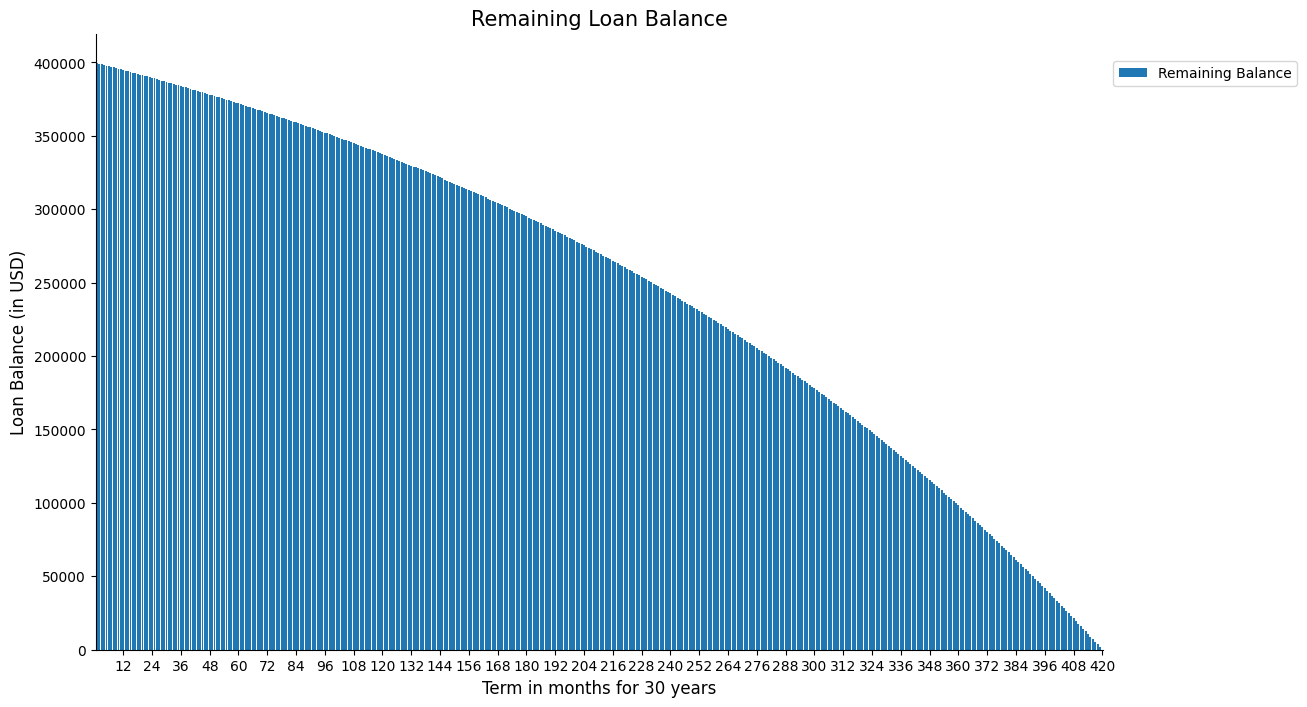

In [39]:
plt.figure(figsize = (13,8))
plt.bar(np.arange(1,m*n_years+1) , -remaining_balance , label = "Remaining Balance")

plt.title("Remaining Loan Balance", fontsize = 15)
plt.xlabel("Term in months for 30 years", fontsize = 12)
plt.ylabel("Loan Balance (in USD)", fontsize = 12)

plt.xticks(np.arange(0,m*n_years+12, 12))

ax = plt.gca()
ax.spines[["right", "top"]].set_visible(False)

plt.autoscale(enable = True , axis = "x" , tight = True)
plt.legend(bbox_to_anchor=(1.01, 0.956), loc='upper left', borderaxespad=0.)
plt.show()

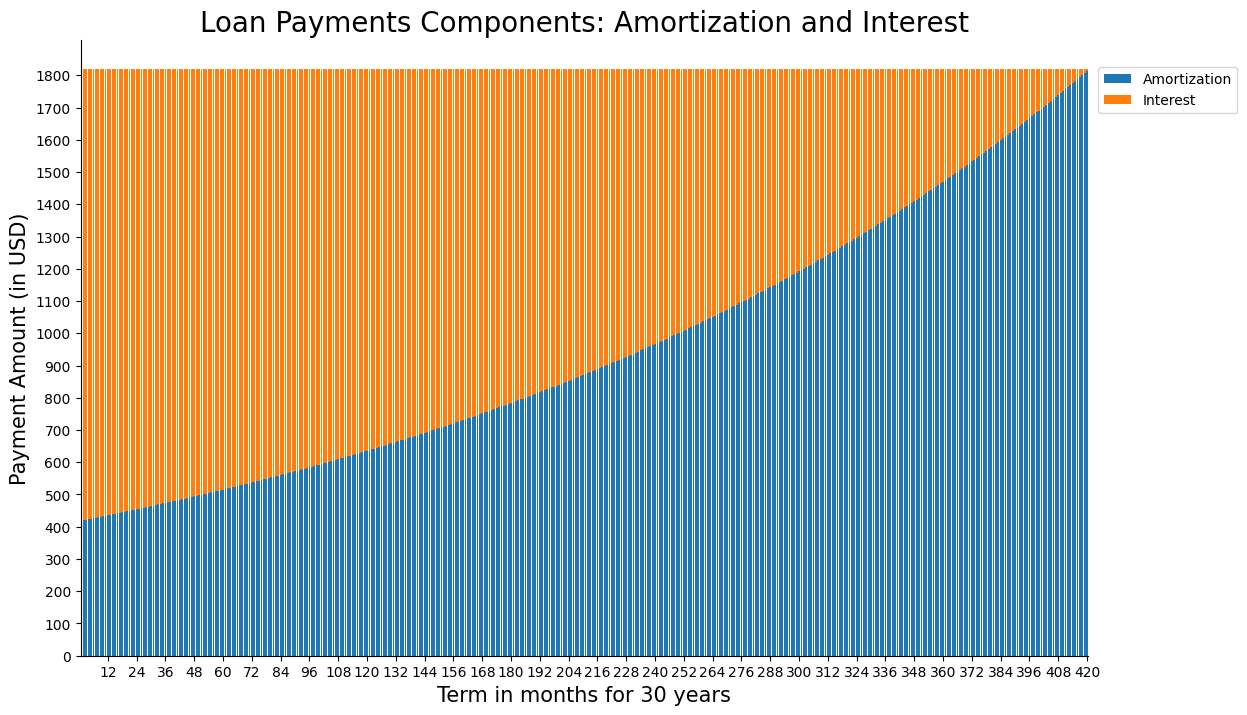

In [40]:
plt.figure(figsize = (13,8))

plt.bar(np.arange(1 , n_years*m+1) , -amortizations ,  label = "Amortization")
plt.bar(np.arange(1 , n_years*m+1) , -interests ,bottom = -amortizations, label = "Interest")

plt.title("Loan Payments Components: Amortization and Interest" , fontsize = 20)
plt.xlabel("Term in months for 30 years", fontsize = 15)
plt.ylabel("Payment Amount (in USD)", fontsize = 15)
ax = plt.gca()
ax.spines[["right", "top"]].set_visible(False)

plt.yticks(np.arange(0 , -amortizations[-1] , 100))
plt.xticks(np.arange(0, n_years*m+12 , 12))

plt.autoscale(enable = True , axis = "x" , tight = True)
plt.legend(bbox_to_anchor=(1.01, 0.956), loc='upper left', borderaxespad=0.)

plt.show()

In [57]:
loan_amount

400000

Ratio : Interest/Loan_amount: 

In [63]:
ratio_int_loan = -interests/loan_amount


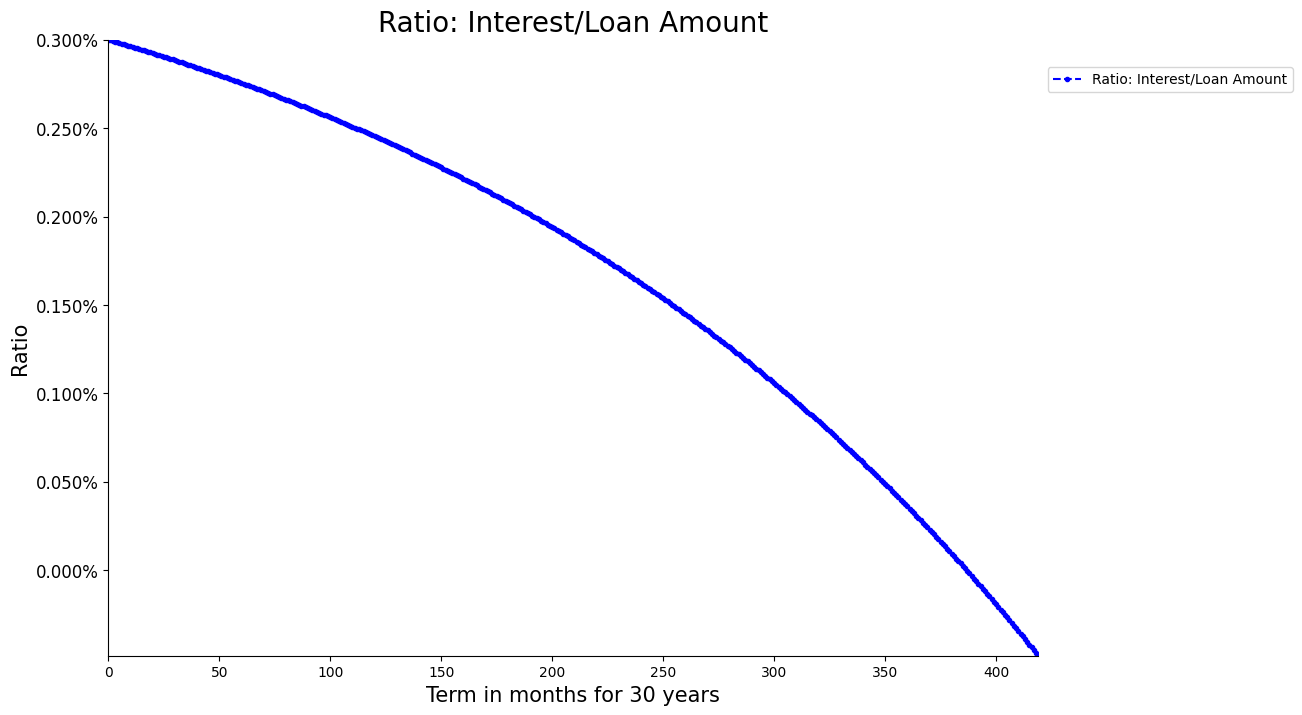

In [78]:
plt.figure(figsize = (12,8))
plt.plot(ratio_int_loan , label = "Ratio: Interest/Loan Amount" , marker = "o" , markersize = 3 , linewidth = 1.5 , ls = "--" , color = "blue")
plt.title("Ratio: Interest/Loan Amount", fontsize = 20)
plt.ylabel("Ratio", fontsize = 15)
plt.xlabel("Term in months for 30 years", fontsize = 15)
#plt.xticks(np.arange(0, n_years*m+12 , 12))

plt.tick_params(axis='y', labelsize=12)

ax = plt.gca()
ax.spines[["right", "top"]].set_visible(False)

yticks = ax.get_yticks()
ax.set_yticklabels([f"{tick*100:.3f}%" for tick in yticks])

plt.autoscale(enable = True , axis = "both" , tight = True)
plt.legend(bbox_to_anchor=(1.01, 0.956), loc='upper left', borderaxespad=0.)

plt.show()

Ration: Amortization / Interest

In [104]:
ratio_amort_int = -amortizations/-interests

In [133]:
min(ratio_amort_int) , max(ratio_amort_int)

(np.float64(0.2995727717617115), np.float64(285.714285714301))

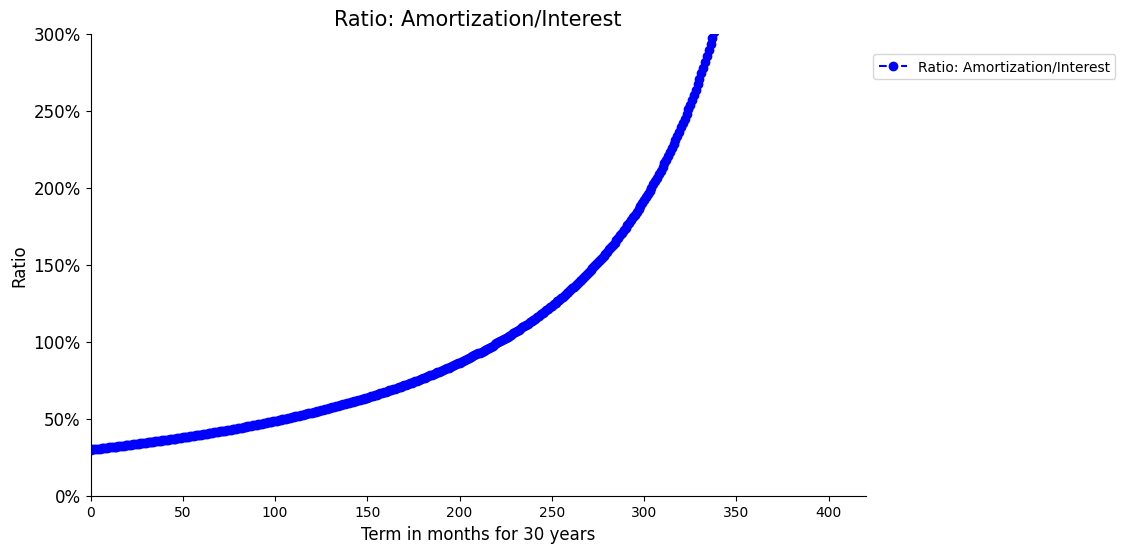

In [ ]:
plt.figure(figsize = (10,6))
plt.plot(ratio_amort_int , label = "Ratio: Amortization/Interest" , marker = "o" , markersize = 6 , linewidth = 1.5 , ls = "--" , color = "blue")
plt.title("Ratio: Amortization/Interest", fontsize = 15)
plt.ylabel("Ratio", fontsize = 12)
plt.xlabel("Term in months for 30 years", fontsize = 12)
#plt.xticks(np.arange(0, n_years*m+12 , 12))

plt.tick_params(axis='y', labelsize=12)

ax = plt.gca()
ax.spines[["right", "top"]].set_visible(False)

ax.set_yticks([0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0])
ax.set_yticklabels(['0%', '50%', '100%', '150%', '200%', '250%', '300%'])
ax.set_ylim(0, 3.0)

plt.xlim((0 , 420))
#plt.ylim((0,350))
plt.legend(bbox_to_anchor=(1.01, 0.956), loc='upper left', borderaxespad=0.)

plt.show()

Ratio: Remaining Loan Balance / Principal Loan Amount

In [110]:
ratio_remaining_to_principal = -remaining_balance/loan_amount

In [137]:
min(ratio_remaining_to_principal) , max(ratio_remaining_to_principal)

(np.float64(0.0), np.float64(0.9989514952988339))

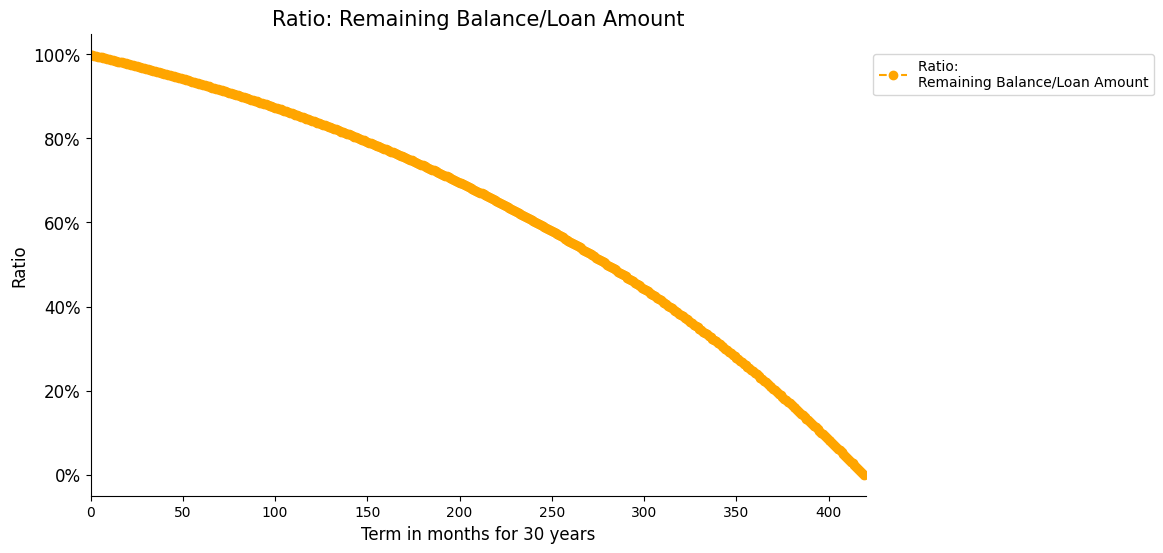

In [121]:
plt.figure(figsize = (10,6))
plt.plot(ratio_remaining_to_principal , label = "Ratio: \nRemaining Balance/Loan Amount" , marker = "o" , markersize = 6 , linewidth = 1.5 , ls = "--" , color = "orange")
plt.title("Ratio: Remaining Balance/Loan Amount", fontsize = 15)
plt.ylabel("Ratio", fontsize = 12)
plt.xlabel("Term in months for 30 years", fontsize = 12)
#plt.xticks(np.arange(0, n_years*m+12 , 12))

plt.tick_params(axis='y', labelsize=12)

ax = plt.gca()
ax.spines[["right", "top"]].set_visible(False)

yticks = ax.get_yticks()
ax.set_yticklabels([f"{tick*100:.0f}%" for tick in yticks])

plt.xlim((0 , 420))

plt.legend(bbox_to_anchor=(1.01, 0.956), loc='upper left', borderaxespad=0.)

plt.show()

In [122]:
# plt.figure(figsize = (13,8))

# ax = plt.gca()
# ax.spines[["right", "top"]].set_visible(False)

# plt.autoscale(enable = True , axis = "x" , tight = True)
# plt.legend(bbox_to_anchor=(1.01, 0.956), loc='upper left', borderaxespad=0.)

# plt.show()

Company ABC evaluates two mutually exclusive Investment Projects (A and B) that lead to the following (estimated) increases in company cashflows/profits (in MUSD):

- Project A: [100, 110, 125, 150, 250, 500]
- Project B: [150, 200, 350, 200, 100, 100]

Both projects require an initial Investment of 800 Million USD (to buy Machinery and Plant).

The projects are mutually exclusive. Assume a company-wide required rate of return of 7.0% p.a. for comparable projects. 

7.  __Which project__ should ABC realize?

In [10]:
# run the cell!
cf_a = np.array([-800, 100, 110, 125, 150, 250, 500])
cf_b = np.array([-800, 150, 200, 350, 200, 100, 100])

In [102]:
r = 7/100
r

0.07

In [17]:
x_axis = np.arange(len(cf_a))
x_axis

array([0, 1, 2, 3, 4, 5, 6])

In [11]:
cum_a = np.cumsum(cf_a)
cum_b = np.cumsum(cf_b)
cum_a , cum_b

(array([-800, -700, -590, -465, -315,  -65,  435]),
 array([-800, -650, -450, -100,  100,  200,  300]))

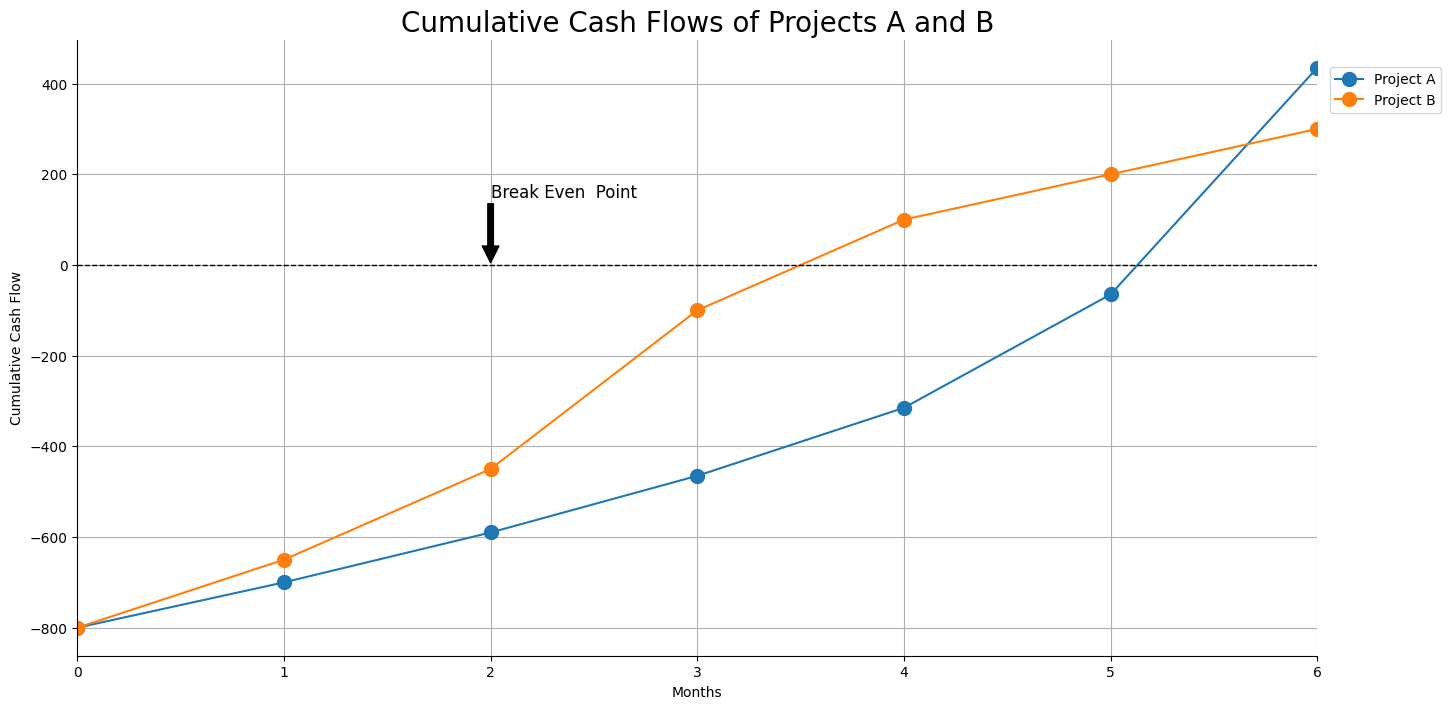

In [124]:
plt.figure(figsize = (16,8))
plt.plot(x_axis , cum_a , marker = "o" , markersize = 10,  label = "Project A")
plt.plot(x_axis , cum_b , marker = "o" , markersize = 10, label = "Project B")

plt.title("Cumulative Cash Flows of Projects A and B", fontsize = 20)
plt.xlabel("Months")
plt.ylabel("Cumulative Cash Flow")

ax = plt.gca()
ax.spines[["right","top"]].set_visible(False)
ax.autoscale(enable = True , axis = "x" , tight = True)
ax.axhline(y = 0 , color = "black", linestyle = "dashed" , linewidth = 1)
ax.annotate(text = "Break Even  Point" , xy = (2 , 5) , xytext = (2,150) , arrowprops = {"color":"black"} , fontsize = 12)

plt.legend(bbox_to_anchor=(1.01, 0.956), loc='upper left', borderaxespad=0.)
plt.grid()
plt.show()

In [12]:
npv_a  = npf.npv(r, cf_a)
npv_b  = npf.npv(r, cf_b)
print(f"npv of project a is: {npv_a:.2f}")
print(f"npv of project b is: {npv_b:.2f}")

npv of project a is: 117.43
npv of project b is: 91.09


In [45]:
rs = np.linspace(0,.25, num = 1000)
rs

array([0.        , 0.00025025, 0.0005005 , 0.00075075, 0.001001  ,
       0.00125125, 0.0015015 , 0.00175175, 0.002002  , 0.00225225,
       0.0025025 , 0.00275275, 0.003003  , 0.00325325, 0.0035035 ,
       0.00375375, 0.004004  , 0.00425425, 0.0045045 , 0.00475475,
       0.00500501, 0.00525526, 0.00550551, 0.00575576, 0.00600601,
       0.00625626, 0.00650651, 0.00675676, 0.00700701, 0.00725726,
       0.00750751, 0.00775776, 0.00800801, 0.00825826, 0.00850851,
       0.00875876, 0.00900901, 0.00925926, 0.00950951, 0.00975976,
       0.01001001, 0.01026026, 0.01051051, 0.01076076, 0.01101101,
       0.01126126, 0.01151151, 0.01176176, 0.01201201, 0.01226226,
       0.01251251, 0.01276276, 0.01301301, 0.01326326, 0.01351351,
       0.01376376, 0.01401401, 0.01426426, 0.01451451, 0.01476476,
       0.01501502, 0.01526527, 0.01551552, 0.01576577, 0.01601602,
       0.01626627, 0.01651652, 0.01676677, 0.01701702, 0.01726727,
       0.01751752, 0.01776777, 0.01801802, 0.01826827, 0.01851

In [ ]:
npvs_a = [] # npvs for project a over the range of interest rates

for r in rs:
    npvs_a.append(npf.npv(r, cf_a))

npvs_a = np.array(npvs_a)
npvs_a

array([ 4.35000000e+02,  4.33613422e+02,  4.32228960e+02,  4.30846612e+02,
        4.29466372e+02,  4.28088237e+02,  4.26712203e+02,  4.25338266e+02,
        4.23966423e+02,  4.22596669e+02,  4.21229000e+02,  4.19863414e+02,
        4.18499906e+02,  4.17138472e+02,  4.15779108e+02,  4.14421811e+02,
        4.13066576e+02,  4.11713401e+02,  4.10362281e+02,  4.09013213e+02,
        4.07666192e+02,  4.06321215e+02,  4.04978279e+02,  4.03637379e+02,
        4.02298511e+02,  4.00961673e+02,  3.99626861e+02,  3.98294070e+02,
        3.96963297e+02,  3.95634538e+02,  3.94307790e+02,  3.92983049e+02,
        3.91660311e+02,  3.90339573e+02,  3.89020831e+02,  3.87704081e+02,
        3.86389320e+02,  3.85076544e+02,  3.83765749e+02,  3.82456933e+02,
        3.81150090e+02,  3.79845219e+02,  3.78542314e+02,  3.77241373e+02,
        3.75942392e+02,  3.74645367e+02,  3.73350295e+02,  3.72057173e+02,
        3.70765996e+02,  3.69476761e+02,  3.68189465e+02,  3.66904105e+02,
        3.65620676e+02,  

In [ ]:
npvs_b = [] # npvs for project b over the range of interest rates


for r in rs:
    npvs_b.append(npf.npv(r, cf_b))

npvs_b = np.array(npvs_b)
npvs_b

array([ 3.00000000e+02,  2.99124653e+02,  2.98250363e+02,  2.97377128e+02,
        2.96504946e+02,  2.95633816e+02,  2.94763736e+02,  2.93894705e+02,
        2.93026720e+02,  2.92159781e+02,  2.91293886e+02,  2.90429032e+02,
        2.89565219e+02,  2.88702445e+02,  2.87840708e+02,  2.86980006e+02,
        2.86120339e+02,  2.85261703e+02,  2.84404099e+02,  2.83547524e+02,
        2.82691976e+02,  2.81837454e+02,  2.80983957e+02,  2.80131482e+02,
        2.79280029e+02,  2.78429595e+02,  2.77580179e+02,  2.76731780e+02,
        2.75884396e+02,  2.75038025e+02,  2.74192666e+02,  2.73348317e+02,
        2.72504976e+02,  2.71662643e+02,  2.70821316e+02,  2.69980992e+02,
        2.69141671e+02,  2.68303351e+02,  2.67466030e+02,  2.66629707e+02,
        2.65794380e+02,  2.64960048e+02,  2.64126710e+02,  2.63294363e+02,
        2.62463006e+02,  2.61632638e+02,  2.60803257e+02,  2.59974862e+02,
        2.59147451e+02,  2.58321022e+02,  2.57495574e+02,  2.56671107e+02,
        2.55847617e+02,  

We choose to contribute to project A  because it has a net present value than project B.

In [13]:
irr_a = npf.irr(cf_a)
irr_b = npf.irr(cf_b)
irr_a , irr_b
print(f"internal rate if return of the ptoject a is: {irr_a*100:.2f}%")
print(f"internal rate if return of the ptoject b is: {irr_b*100:.2f}%")

internal rate if return of the ptoject a is: 10.51%
internal rate if return of the ptoject b is: 10.90%


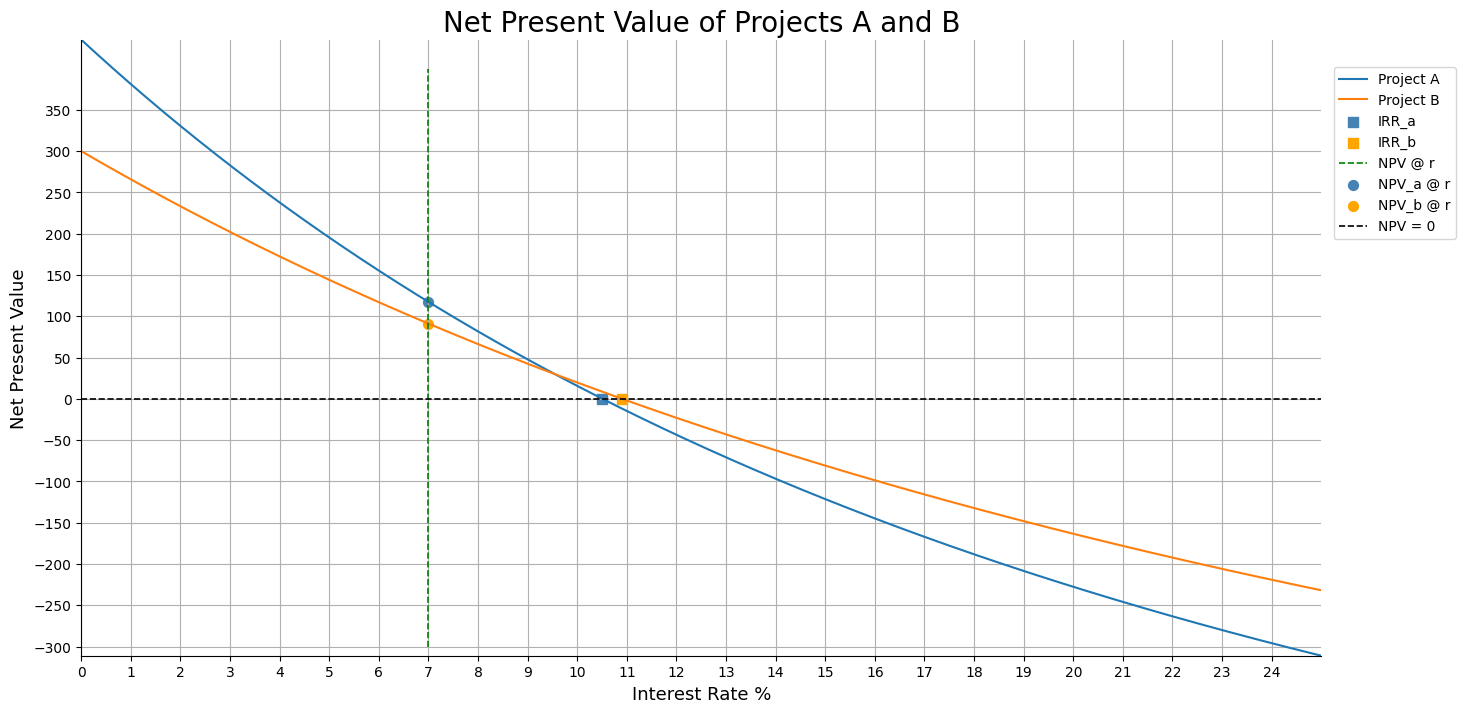

In [116]:
plt.figure(figsize = (16,8))

plt.plot(rs , npvs_a , label = "Project A")
plt.plot(rs , npvs_b , label = "Project B")

plt.scatter(x = irr_a , y = 0 , color = "steelblue" , s = 50 , marker = "s" , label = "IRR_a")
plt.scatter(x = irr_b , y = 0 , color = "orange" , s = 50 , marker = "s" , label = "IRR_b")
plt.vlines(x = r , ymin = -300 , ymax = 400 , color = "green" , linestyle = "dashed" , linewidth = 1.2 , label = "NPV @ r")
plt.scatter(r , npf.npv(r , cf_a) , color = "steelblue" , s = 50 , marker = "o" , label = "NPV_a @ r")
plt.scatter(r , npf.npv(r , cf_b) , color = "orange" , s = 50 , marker = "o" , label = "NPV_b @ r")


plt.ylabel("Net Present Value" , fontsize = 13)
plt.xlabel("Interest Rate %" , fontsize = 13)
plt.title("Net Present Value of Projects A and B" , fontsize = 20)

ax = plt.gca()
ax.spines[["right","top"]].set_visible(False)
ax.autoscale(enable = True , axis = "both" , tight = True)
ax.axhline(y = 0 , color = "black", linestyle = "dashed" , linewidth = 1.2 , label = "NPV = 0" )


plt.yticks(np.arange(-300 , 400 , 50))
plt.xticks(np.arange(0 , 0.25 , 0.01) , labels = np.arange(0 , 25 , 1))

plt.legend(bbox_to_anchor=(1.01, 0.956), loc='upper left', borderaxespad=0.)
plt.grid()
plt.show()

In [133]:
print("After the project a, we can have a free cash flow of $" , np.around(npv_a,2))

After the project a, we can have a free cash flow of $ 117.43


In [132]:
print("After the project b, we can have a free cash flow of $" , np.around(npv_b ,2))

After the project b, we can have a free cash flow of $ 91.09


So we should choose project A.

8. Calculate the (hypothetical) required rate of return where your decision would change (__crossover rate__).

In [14]:
diff_project = cf_a - cf_b


In [15]:
npf.irr(diff_project)

0.09549161767250536

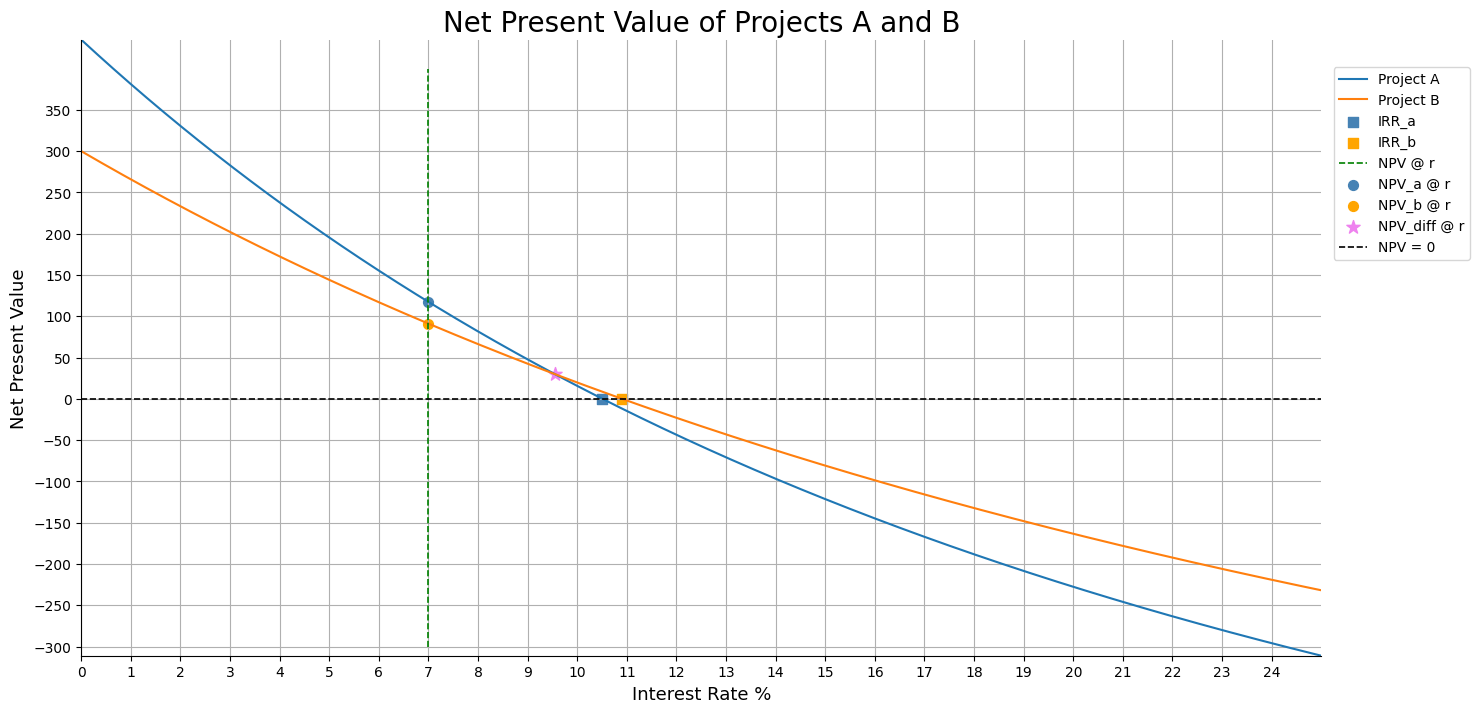

In [123]:
plt.figure(figsize = (16,8))

plt.plot(rs , npvs_a , label = "Project A")
plt.plot(rs , npvs_b , label = "Project B")

plt.scatter(x = irr_a , y = 0 , color = "steelblue" , s = 50 , marker = "s" , label = "IRR_a")
plt.scatter(x = irr_b , y = 0 , color = "orange" , s = 50 , marker = "s" , label = "IRR_b")
plt.vlines(x = r , ymin = -300 , ymax = 400 , color = "green" , linestyle = "dashed" , linewidth = 1.2 , label = "NPV @ r")
plt.scatter(r , npf.npv(r , cf_a) , color = "steelblue" , s = 50 , marker = "o" , label = "NPV_a @ r")
plt.scatter(r , npf.npv(r , cf_b) , color = "orange" , s = 50 , marker = "o" , label = "NPV_b @ r")
plt.scatter(npf.irr(diff_project) , npf.npv(npf.irr(diff_project) , cf_a) , color = "violet" , s = 100 , marker = "*" , label = "NPV_diff @ r")


plt.ylabel("Net Present Value" , fontsize = 13)
plt.xlabel("Interest Rate %" , fontsize = 13)
plt.title("Net Present Value of Projects A and B" , fontsize = 20)

ax = plt.gca()
ax.spines[["right","top"]].set_visible(False)
ax.autoscale(enable = True , axis = "both" , tight = True)
ax.axhline(y = 0 , color = "black", linestyle = "dashed" , linewidth = 1.2 , label = "NPV = 0" )


plt.yticks(np.arange(-300 , 400 , 50))
plt.xticks(np.arange(0 , 0.25 , 0.01) , labels = np.arange(0 , 25 , 1))

plt.legend(bbox_to_anchor=(1.01, 0.956), loc='upper left', borderaxespad=0.)
plt.grid()
plt.show()

# Well Done!

---------------------------------------------------------------------------------------------------------------------